# vLLM Heuristic Profiling Compare

Compare FlashDecoding heuristic against the best measured choice among FA and profile-selected FlashDecoding chunk settings for fixed `n_beams * padded_prompt_len = 2048` and `GEN_LEN = 20`.

Before launching this notebook in the `sal_new_vllm` environment, run:

```bash
export VLLM_USE_V1=1
export VLLM_ATTENTION_BACKEND=TRITON_ATTN_VLLM_V1
export VLLM_ENABLE_V1_MULTIPROCESSING=0
conda activate sal_new_vllm
jupyter lab
```

In [2]:
import os

# Keep these here too so a clean kernel matches the shell setup exactly.
# For a fresh vLLM import, the shell exports above are still preferred.
os.environ["VLLM_USE_V1"] = "1"
os.environ["VLLM_ATTENTION_BACKEND"] = "TRITON_ATTN_VLLM_V1"
os.environ["VLLM_ENABLE_V1_MULTIPROCESSING"] = "0"

import math
import sys
import time
import traceback
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from datasets import load_dataset
from vllm import LLM, SamplingParams
from vllm.attention.ops import chunked_prefill_paged_decode as cpd
from vllm.inputs import TokensPrompt

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src" / "sal").exists():
    PROJECT_ROOT = Path(".")
sys.path.insert(0, str(PROJECT_ROOT / "src"))
sys.path.insert(0, str(PROJECT_ROOT))

from sal.config import _SYSTEM_PROMPT_MATH500, Config
from sal.utils.parser import H4ArgumentParser

# Keep this notebook's FD heuristic self-contained so it mirrors xformers'
# split-K selection directly instead of depending on SAL's local port.

RECIPE_PATH = PROJECT_ROOT / "recipes" / "best-of-n.yaml"
print(f"project root: {PROJECT_ROOT}")
print(f"recipe: {RECIPE_PATH}")

<CONDA_ENV>/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
<CONDA_ENV>/lib/python3.11/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


INFO 07-18 00:21:10 [__init__.py:239] Automatically detected platform cuda.


2026-07-18 00:21:12,359	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


WARNING 07-18 00:21:12 [rocm.py:24] Failed to import from amdsmi with ModuleNotFoundError("No module named 'amdsmi'")
WARNING 07-18 00:21:12 [rocm.py:35] Failed to import from vllm._rocm_C with ModuleNotFoundError("No module named 'vllm._rocm_C'")
project root: .
recipe: ./recipes/best-of-n.yaml


## Experiment Constants

In [3]:
SEED = 0
BLOCK_SIZE = 16
GEN_LEN = 20
NUM_LAYER = 28
PROMPT_TOKEN_BUDGET = 4096
# # Product = 2048
# N_BEAMS_LIST = [1, 2, 4, 8, 16, 32, 64, 128]
# CHUNK_SIZE_PAGE_LIST = [4, 6, 8, 16, 32, 64]
# Product = 4096
N_BEAMS_LIST = [1, 2, 4, 8, 16, 24, 32, 40, 48, 56, 64]
CHUNK_SIZE_PAGE_LIST = [4, 6, 8, 16, 32, 64]

# Step 6 constants: one entry per N_BEAMS_LIST element.
# Product = 2048
# ATTN_BASE_US = [123.936, 66.208, 34.784, 18.688, 13.536, 13.536, 13.664, 16.832]
# ATTN_RATIO = [123.936/247.258, 66.208/195.961, 34.784/183.309, 18.688/167.473, 13.536/146.608, 13.536/150.832, 13.664/159.280, 16.832/176.040]
# Product = 4096
ATTN_BASE_US = [268.833, 140.993, 77.792, 46.336, \
                30.752, 25.440, 23.456, 21.280, \
                20.608, 19.488, 20.192]
ATTN_RATIO = [268.833/391.910, 140.993/270.157, 77.792/227.172, 46.336/195.536, \
              30.752/164.339, 25.440/159.515, 23.456/161.070, 21.280/160.721, \
              20.608/164.220, 19.488/164.592, 20.192/165.070]
assert len(ATTN_BASE_US) == len(N_BEAMS_LIST)
assert len(ATTN_RATIO) == len(N_BEAMS_LIST)

# Number of repeated measurements per variant. min() is reported, matching the
# spirit of chunk_setting_profile.py's first-beam timing under warmed kernels.
MEASURE_REPEATS = 1

RESULTS_CSV = PROJECT_ROOT / "scripts" / "vllm_heuristic_profiling_compare_results.csv"
RESULTS_CSV

PosixPath('./scripts/vllm_heuristic_profiling_compare_results.csv')

## Load Recipe And First MATH-500 Problem

In [4]:
print(RECIPE_PATH.read_text())

parser = H4ArgumentParser(Config)
parsed = parser.parse_yaml_file(str(RECIPE_PATH))
config = parsed[0] if isinstance(parsed, (list, tuple)) else parsed

# This notebook intentionally profiles MATH-500 prompt construction even if the
# recipe is currently pointed at another dataset.
config.dataset_name = "HuggingFaceH4/MATH-500"
config.dataset_split = "test"
config.system_prompt = _SYSTEM_PROMPT_MATH500
os.environ["VLLM_TRITON_DECODE_KERNEL"] = config.triton_decode_kernel

math500 = load_dataset(config.dataset_name, split=config.dataset_split)
first_row = math500[0]
for col in ["problem", "question", "prompt"]:
    if col in first_row:
        first_problem = first_row[col]
        break
else:
    raise KeyError(f"Could not find a problem column. Columns: {list(first_row.keys())}")

print(f"model_path: {config.model_path}")
print(f"gpu_memory_utilization: {config.gpu_memory_utilization}")
print(f"first problem column: {col}")
print(first_problem[:500])

# refer to src/sal/config.py for more options

dataset_name: HuggingFaceH4/MATH-500
dataset_split: test
# dataset_name: AI-MO/aimo-validation-aime
# dataset_split: train
model_path: Qwen/QWen2.5-1.5B-Instruct
prm_path: Skywork/Skywork-o1-Open-PRM-Qwen-2.5-1.5B
gpu_memory_utilization: 0.9
custom_chat_template: null
approach: best_of_n
n: 128
search_batch_size: 1
timing_enabled: false
sort_completed: true
filter_duplicates: true
# num_samples: 1         # REMOVE THIS LINE TO RUN ON THE WHOLE DATASET
seed: 0
push_to_hub: false
max_tokens: 2048
gemm_opt: false
chunk_size: none     # [dynamic, heuristic, none]
disable_prm: true
# padded_prompt_len: 2048   # 0 = no padding; otherwise left-pad templated prompt to this many tokens
model_path: Qwen/QWen2.5-1.5B-Instruct
gpu_memory_utilization: 0.9
first problem column: problem
Convert the point $(0,3)$ in rectangular coordinates to polar coordinates.  Enter your answer in the form $(r,\theta),$ where $r > 0$ and $0 \le \theta < 2 \pi.$


## Profiling Helpers

In [5]:
def find_single_token_pad(tokenizer):
    for text in [" x", " 0", " a", "x", "0", "a"]:
        ids = tokenizer.encode(text, add_special_tokens=False)
        if len(ids) == 1:
            return ids[0]
    raise RuntimeError("Could not find a single-token pad string for this tokenizer")


def build_token_ids(tokenizer, system_prompt, user_msg, padded_prompt_len, pad_id):
    """Build system + user chat prompt, then append padded_prompt_len pad tokens.

    actual_total_prompt_len = len(chat_template(system_prompt, first_problem)) + padded_prompt_len.
    """
    msgs = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_msg},
    ]
    base_ids = tokenizer.apply_chat_template(msgs, tokenize=True, add_generation_prompt=True)
    base_len = len(base_ids)
    return list(base_ids) + [pad_id] * padded_prompt_len, base_len, padded_prompt_len


def drain(engine):
    while engine.has_unfinished_requests():
        engine.step()


def measure_first_beam_ms(llm, n_beams, token_ids, gen_tokens):
    """Same measurement target as chunk_setting_profile.py.

    Submit n_beams identical requests and return milliseconds from request
    submission to completion of profile-0. Remaining beams are aborted once
    profile-0 finishes.
    """
    engine = llm.llm_engine
    sp = SamplingParams(
        temperature=0.8,
        top_p=1.0,
        seed=SEED,
        n=1,
        max_tokens=gen_tokens,
        min_tokens=gen_tokens,
    )
    drain(engine)

    rids = [f"profile-{i}" for i in range(n_beams)]
    start_times = {}
    for rid in rids:
        engine.add_request(rid, TokensPrompt(prompt_token_ids=token_ids), sp)
        start_times[rid] = time.perf_counter()

    target = rids[0]
    end_t = None
    while engine.has_unfinished_requests():
        outputs = engine.step()
        for output in outputs:
            if output.finished and output.request_id == target:
                end_t = time.perf_counter()
                break
        if end_t is not None:
            for other in rids[1:]:
                try:
                    engine.abort_request(other)
                except Exception:
                    pass
            drain(engine)
            break

    if end_t is None:
        raise RuntimeError(f"profile-0 never reported finished (n_beams={n_beams})")
    return (end_t - start_times[target]) * 1000.0


def model_head_info(llm):
    hf_config = llm.llm_engine.model_config.hf_config
    num_query_heads = getattr(hf_config, "num_attention_heads")
    num_kv_heads = getattr(hf_config, "num_key_value_heads", num_query_heads)
    num_queries_per_kv = num_query_heads // num_kv_heads
    return num_query_heads, num_kv_heads, num_queries_per_kv


def xformers_bmghk_dims(num_query_heads, num_kv_heads):
    """Map vLLM head counts to xformers' original BMGHK convention.

    Original xformers unpacks q as [B, Mq, G, H, K], where G is
    head_groups and H is num_heads_per_group. For a GQA model, the
    equivalent grouping is G=num_kv_heads and H=q_heads_per_kv_head.
    """
    if num_query_heads % num_kv_heads != 0:
        raise ValueError(f"num_query_heads={num_query_heads} is not divisible by num_kv_heads={num_kv_heads}")
    G = num_kv_heads
    H = num_query_heads // num_kv_heads
    return G, H


def xformers_get_split_k(B, G, H, Mk, Mq=1):
    """xformers FwOp.get_split_k heuristic for CUDA decode.

    xformers uses BMGHK notation:
      B: batch / live sequence count
      G: head_groups from q.shape[2]
      H: num_heads_per_group from q.shape[3]
      Mk: KV length
      Mq: query length
    """
    bh = max(B * H, 1)
    if Mq > 1 and B * G * H > 64:
        return 1
    split_k = max(Mk, 1024) // bh
    max_chunk_size = 64 if Mk <= 512 and bh <= 64 else 128
    split_k_stop_val = Mk / max_chunk_size
    while split_k > split_k_stop_val:
        split_k //= 2
    split_k = min(split_k, 64)
    split_k = max(split_k, 1)
    return split_k


def fd_heuristic_chunk_size_page(n_beams, actual_total_prompt_len, xformers_G, xformers_H):
    """xformers/FlashDecoding heuristic mapped to cpd.PROFILE_CHUNK_SIZE_PAGE."""
    split_k = xformers_get_split_k(
        B=n_beams,
        G=xformers_G,
        H=xformers_H,
        Mk=actual_total_prompt_len,
        Mq=1,
    )
    if split_k <= 1:
        return math.ceil(actual_total_prompt_len / BLOCK_SIZE), split_k
    tokens_per_split = math.ceil(actual_total_prompt_len / split_k)
    return max(1, math.ceil(tokens_per_split / BLOCK_SIZE)), split_k


def global_warmup(llm, tokenizer, system_prompt, sample_user, pad_id):
    warmup_len = 256
    token_ids, base_len, _ = build_token_ids(tokenizer, system_prompt, sample_user, warmup_len, pad_id)
    if token_ids is None:
        token_ids = tokenizer.apply_chat_template(
            [{"role": "system", "content": system_prompt}, {"role": "user", "content": sample_user}],
            tokenize=True,
            add_generation_prompt=True,
        )
    prev = cpd.PROFILE_CHUNK_SIZE_PAGE
    try:
        cpd.PROFILE_CHUNK_SIZE_PAGE = None
        measure_first_beam_ms(llm, 1, token_ids, GEN_LEN)
        cpd.PROFILE_CHUNK_SIZE_PAGE = 4
        measure_first_beam_ms(llm, 1, token_ids, GEN_LEN)
    finally:
        cpd.PROFILE_CHUNK_SIZE_PAGE = prev


def measure_variant(llm, n_beams, token_ids, gen_tokens, csp, repeats=MEASURE_REPEATS):
    prev = cpd.PROFILE_CHUNK_SIZE_PAGE
    times = []
    try:
        cpd.PROFILE_CHUNK_SIZE_PAGE = csp
        for _ in range(repeats):
            times.append(measure_first_beam_ms(llm, n_beams, token_ids, gen_tokens))
    finally:
        cpd.PROFILE_CHUNK_SIZE_PAGE = prev
    return min(times)


def per_beam_value(values, n_beams):
    if isinstance(values, (list, tuple, np.ndarray, pd.Series)):
        if len(values) != len(N_BEAMS_LIST):
            raise ValueError(f"Expected {len(N_BEAMS_LIST)} entries, got {len(values)}")
        return float(values[N_BEAMS_LIST.index(int(n_beams))])
    return float(values)


def attention_constants_for_beam(n_beams):
    return per_beam_value(ATTN_BASE_US, n_beams), per_beam_value(ATTN_RATIO, n_beams)


def attn_latency_us(fa_time_ms, variant_time_ms, attn_base_us, attn_ratio):
    """attn_base - (A - variant) / attn_ratio, with measured times in ms."""
    return attn_base_us - ((fa_time_ms - variant_time_ms) * 1000.0) / GEN_LEN / NUM_LAYER / attn_ratio

## Initialize vLLM

In [ ]:
llm = LLM(
    model=config.model_path,
    gpu_memory_utilization=config.gpu_memory_utilization,
    enable_prefix_caching=True,
    seed=SEED,
    load_format="safetensors",
    task="generate",
    dtype="auto",
    max_num_seqs=max(N_BEAMS_LIST),
    disable_cascade_attn=True,
)
tokenizer = llm.get_tokenizer()
if config.custom_chat_template is not None:
    tokenizer.chat_template = config.custom_chat_template

pad_id = find_single_token_pad(tokenizer)
num_query_heads, num_kv_heads, num_queries_per_kv = model_head_info(llm)
xformers_G, xformers_H = xformers_bmghk_dims(num_query_heads, num_kv_heads)
print(f"pad_id: {pad_id}")
print(f"heads: q={num_query_heads}, kv={num_kv_heads}, q_per_kv={num_queries_per_kv}")
print(f"xformers BMGHK dims: G={xformers_G}, H={xformers_H}")

print("Warming FA and FD paths...")
global_warmup(llm, tokenizer, config.system_prompt, "Solve: 2+2=?", pad_id)
print("Warmup done.")

## Build Prompt Targets

In [7]:
prompt_rows = []
for n_beams in N_BEAMS_LIST:
    padded_prompt_len = PROMPT_TOKEN_BUDGET // n_beams
    # assert n_beams * padded_prompt_len == PROMPT_TOKEN_BUDGET
    token_ids, base_len, pad_len = build_token_ids(
        tokenizer, config.system_prompt, first_problem, padded_prompt_len, pad_id
    )
    actual_total_prompt_len = base_len + pad_len
    prompt_rows.append({
        "n_beams": n_beams,
        "base_prompt_len": base_len,
        "padded_prompt_len": pad_len,
        "actual_total_prompt_len": actual_total_prompt_len,
    })

prompt_df = pd.DataFrame(prompt_rows)
display(prompt_df)

print("actual_total_prompt_len = base_prompt_len + padded_prompt_len")

NameError: name 'tokenizer' is not defined

## Run Profiling Sweep

In [8]:
rows = []

for prompt_row in prompt_rows:
    n_beams = prompt_row["n_beams"]
    padded_prompt_len = prompt_row["padded_prompt_len"]
    actual_total_prompt_len = prompt_row["actual_total_prompt_len"]
    print(f"\n=== n_beams={n_beams}, padded_prompt_len={padded_prompt_len}, actual_total_prompt_len={actual_total_prompt_len} ===")

    token_ids, base_len, pad_len = build_token_ids(
        tokenizer, config.system_prompt, first_problem, padded_prompt_len, pad_id
    )
    actual_total_prompt_len = len(token_ids)

    fa_time_ms = np.nan
    try:
        fa_time_ms = measure_variant(llm, n_beams, token_ids, GEN_LEN, csp=None)
        rows.append({
            "n_beams": n_beams,
            "base_prompt_len": base_len,
            "padded_prompt_len": pad_len,
            "actual_total_prompt_len": actual_total_prompt_len,
            "variant": "FA",
            "chunk_size_page": np.nan,
            "split_k": np.nan,
            "time_ms": fa_time_ms,
            "note": "",
        })
        print(f"FA: {fa_time_ms:.3f} ms")

        heuristic_csp, split_k = fd_heuristic_chunk_size_page(
            n_beams, actual_total_prompt_len, xformers_G, xformers_H
        )
        heuristic_chunk_tokens = heuristic_csp * BLOCK_SIZE
        heuristic_is_no_chunk = split_k <= 1 or heuristic_chunk_tokens >= actual_total_prompt_len
        if heuristic_is_no_chunk:
            heuristic_time_ms = fa_time_ms
            heuristic_note = "heuristic selected no chunk; reused FA time"
        else:
            heuristic_time_ms = measure_variant(llm, n_beams, token_ids, GEN_LEN, csp=heuristic_csp)
            heuristic_note = ""
        rows.append({
            "n_beams": n_beams,
            "base_prompt_len": base_len,
            "padded_prompt_len": pad_len,
            "actual_total_prompt_len": actual_total_prompt_len,
            "variant": "FD_heuristic",
            "chunk_size_page": heuristic_csp,
            "split_k": split_k,
            "time_ms": heuristic_time_ms,
            "note": heuristic_note,
        })
        print(f"FD_heuristic: csp={heuristic_csp}, split_k={split_k}, {heuristic_time_ms:.3f} ms {heuristic_note}")

        profiling_candidates = [(fa_time_ms, np.nan, "FA")]
        print(f"our_profiling candidate FA: {fa_time_ms:.3f} ms")
        for csp in CHUNK_SIZE_PAGE_LIST:
            candidate_time_ms = measure_variant(llm, n_beams, token_ids, GEN_LEN, csp=csp)
            profiling_candidates.append((candidate_time_ms, csp, f"FD-{csp}"))
            print(f"our_profiling candidate FD-{csp}: {candidate_time_ms:.3f} ms")

        best_time_ms, best_csp, best_profile_variant = min(profiling_candidates, key=lambda item: item[0])
        rows.append({
            "n_beams": n_beams,
            "base_prompt_len": base_len,
            "padded_prompt_len": pad_len,
            "actual_total_prompt_len": actual_total_prompt_len,
            "variant": "our_profiling",
            "chunk_size_page": best_csp,
            "split_k": np.nan,
            "time_ms": best_time_ms,
            "note": f"best={best_profile_variant}; candidates=FA + {CHUNK_SIZE_PAGE_LIST}",
        })
        print(f"our_profiling: best={best_profile_variant}, best_csp={best_csp}, {best_time_ms:.3f} ms")

    except torch.cuda.OutOfMemoryError as exc:
        torch.cuda.empty_cache()
        try:
            drain(llm.llm_engine)
        except Exception:
            pass
        rows.append({
            "n_beams": n_beams,
            "base_prompt_len": base_len,
            "padded_prompt_len": pad_len,
            "actual_total_prompt_len": actual_total_prompt_len,
            "variant": "ERR",
            "chunk_size_page": np.nan,
            "split_k": np.nan,
            "time_ms": np.nan,
            "note": f"OOM: {exc}",
        })
        print(f"OOM: {exc}")
    except Exception as exc:
        rows.append({
            "n_beams": n_beams,
            "base_prompt_len": base_len,
            "padded_prompt_len": pad_len,
            "actual_total_prompt_len": actual_total_prompt_len,
            "variant": "ERR",
            "chunk_size_page": np.nan,
            "split_k": np.nan,
            "time_ms": np.nan,
            "note": f"ERR: {type(exc).__name__}: {exc}",
        })
        print(traceback.format_exc())

    pd.DataFrame(rows).to_csv(RESULTS_CSV, index=False)

raw_df = pd.DataFrame(rows)
raw_df.to_csv(RESULTS_CSV, index=False)
display(raw_df)
print(f"saved: {RESULTS_CSV}")

""


saved: ./scripts/vllm_heuristic_profiling_compare_results.csv


## Post-process Attention Latency

In [ ]:
raw_df = pd.read_csv(RESULTS_CSV)
valid_df = raw_df[raw_df["variant"].isin(["FA", "FD_heuristic", "our_profiling"])].copy()

latency_rows = []
for (n_beams, actual_total_prompt_len), group in valid_df.groupby(["n_beams", "actual_total_prompt_len"]):
    times = group.set_index("variant")["time_ms"]
    if "FA" not in times or pd.isna(times["FA"]):
        continue

    # A, B, C are measured in milliseconds by measure_first_beam_ms().
    # The latency output is microseconds, so (A - B) and (A - C) are converted to us.
    A = float(times["FA"])
    attn_base_us, attn_ratio = attention_constants_for_beam(n_beams)

    for variant in ["FD_heuristic", "our_profiling"]:
        if variant not in times or pd.isna(times[variant]):
            continue
        variant_time_ms = float(times[variant])
        row = group[group["variant"] == variant].iloc[0]
        chunk_size_page = row["chunk_size_page"]
        note = str(row.get("note", ""))
        if variant == "FD_heuristic" and "no chunk" in note:
            chunk_size_page = np.nan
        latency_rows.append({
            "n_beams": n_beams,
            "actual_total_prompt_len": actual_total_prompt_len,
            "variant": variant,
            "chunk_size_page": chunk_size_page,
            "fa_time_ms": A,
            "variant_time_ms": variant_time_ms,
            "attn_base_us": attn_base_us,
            "attn_ratio": attn_ratio,
            "attn_latency_us": attn_latency_us(A, variant_time_ms, attn_base_us, attn_ratio),
        })

latency_df = pd.DataFrame(latency_rows)
display(latency_df)
latency_df.to_csv(RESULTS_CSV.with_name("vllm_heuristic_profiling_compare_attn_latency.csv"), index=False)

## Plot

saved: ./scripts/vllm_heuristic_profiling_compare_attn_latency.png


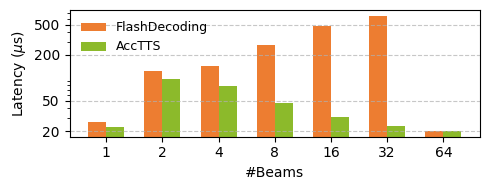

In [25]:
# Plot directly from the saved attention-latency CSV.
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import NullFormatter, ScalarFormatter

csv_path = Path("vllm_heuristic_profiling_compare_attn_latency.csv")
if not csv_path.exists():
    csv_path = Path("./scripts/vllm_heuristic_profiling_compare_attn_latency.csv")

plot_df = pd.read_csv(csv_path)
plot_df = plot_df[plot_df["variant"].isin(["FD_heuristic", "our_profiling"])].copy()
plot_df["n_beams"] = plot_df["n_beams"].astype(int)

variant_order = ["FD_heuristic", "our_profiling"]
label_map = {
    "FD_heuristic": "FlashDecoding",
    "our_profiling": "AccTTS",
}
colors = {
    "FD_heuristic": "#ed7d31",
    "our_profiling": "#8cba2b",
}

# Directly use every beam setting present in the CSV. To restrict the plot,
# replace this line with e.g. `beams = [1, 2, 4, 8, 16, 32, 64]`.
beams = [1, 2, 4, 8, 16, 32, 64]
x = np.arange(len(beams))
width = 0.32

fig, ax = plt.subplots(figsize=(5, 2))
for i, variant in enumerate(variant_order):
    values = []
    for beam in beams:
        match = plot_df[(plot_df["n_beams"] == beam) & (plot_df["variant"] == variant)]
        values.append(match.iloc[0]["attn_latency_us"] if not match.empty else np.nan)
    ax.bar(
    x + (i - 0.5) * width,
    values,
    width,
    label=label_map[variant],
    color=colors[variant],
)

ax.set_xticks(x)
ax.set_yscale('log')
ax.set_yticks([20, 50, 200, 500])
ax.set_yticklabels(["20", "50", '200', "500"])
ax.set_xticklabels([str(b) for b in beams])
ax.set_xlabel("#Beams", fontsize = 10)
ax.set_ylabel(r"Latency ($\mu$s)", fontsize = 10)
ax.tick_params(axis='both', labelsize=10)
ax.legend(
    frameon=False,
    fontsize=9,
    loc="upper left",
    bbox_to_anchor=(0.0, 1.0),
)
ax.grid(axis="y", alpha=0.7, linestyle='--')
fig.tight_layout()

plot_path = RESULTS_CSV.with_name("vllm_heuristic_profiling_compare_attn_latency.png")
fig.savefig(plot_path, dpi=300)
print(f"saved: {plot_path}")
